In [16]:
import pandas as pd
import numpy as np

file_path_cw = 'robot_rotation_twist_estimated_angle_data_cw.csv'  
file_path_ccw = 'robot_rotation_twist_estimated_angle_data.csv'  

try:
    
    dfcw = pd.read_csv(file_path_cw)
    print(f"--- Data from '{file_path_cw}' ---")
    print(dfcw.head())  
    print(f"Shape of df1: {dfcw.shape}") 

    print("\n" + "="*50 + "\n")

    
    dfccw = pd.read_csv(file_path_ccw)
    print(f"--- Data from '{file_path_ccw}' ---")
    print(dfccw.head()) 
    print(f"Shape of df2: {dfccw.shape}") 

except FileNotFoundError:
    print("Error: One or both of the CSV files were not found. Please check the file paths.")
except Exception as e:
    print(f"An error occurred: {e}")


--- Data from 'robot_rotation_twist_estimated_angle_data_cw.csv' ---
   Iteration   Final_X   Final_Y  Final_Yaw_Rad  Final_Yaw_Deg
0          1  0.006014  0.004321      -1.571285     -90.027971
1          2  0.006002  0.004317      -1.571295     -90.028556
2          3  0.005997  0.004316      -1.571223     -90.024436
3          4  0.006009  0.004318      -1.571376     -90.033226
4          5  0.005994  0.004317      -1.571180     -90.022006
Shape of df1: (20, 5)


--- Data from 'robot_rotation_twist_estimated_angle_data.csv' ---
   Iteration   Final_X   Final_Y  Final_Yaw_Rad  Final_Yaw_Deg
0          1  0.006532 -0.008320       1.572086      90.073914
1          2  0.006526 -0.008324       1.572097      90.074511
2          3  0.006537 -0.008324       1.572092      90.074231
3          4  0.006540 -0.008326       1.572125      90.076113
4          5  0.006528 -0.008324       1.572001      90.069051
Shape of df2: (20, 5)


In [15]:
def calculate_values(df):
    miu = 0.5*(df['Final_X']/df['Final_Y'])
    x_star = df['Final_X']/2 + miu*(0-df['Final_Y'])
    y_star = df['Final_Y']/2 + miu*(df['Final_X']-0)
    r_star = np.sqrt(x_star**2 + y_star**2)
    delta_t = 90/30
    delta_theta = np.atan2(df['Final_Y']-y_star , df['Final_X']-x_star) - np.atan2(0-y_star , 0 -x_star)

    v_hat = delta_theta*r_star/delta_t

    omega_hat = delta_theta/delta_t

    gamma_hat = df['Final_Yaw_Rad']/delta_t - omega_hat

    return v_hat , omega_hat , gamma_hat

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
def visualize_dataframe(df , name):
    sns.set_style("whitegrid")

    # Create the KDE plot
    plt.figure(figsize=(10, 6)) 
    sns.kdeplot(df, fill=True, color="skyblue", bw_adjust=0.5)
    plt.title(f'Kernel Density Estimate (KDE) Plot of {name}', fontsize=16)
    plt.xlabel(f'{name}', fontsize=14)
    plt.ylabel('Density', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.7) 
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 6)) 
    sns.histplot(df, bins=30, kde=True, color="lightcoral", edgecolor="black")
    plt.title(f'Histogram of {name}', fontsize=16)
    plt.xlabel(f'{name}', fontsize=14)
    plt.ylabel('Frequency', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.7) 
    plt.tight_layout() 
    plt.show()



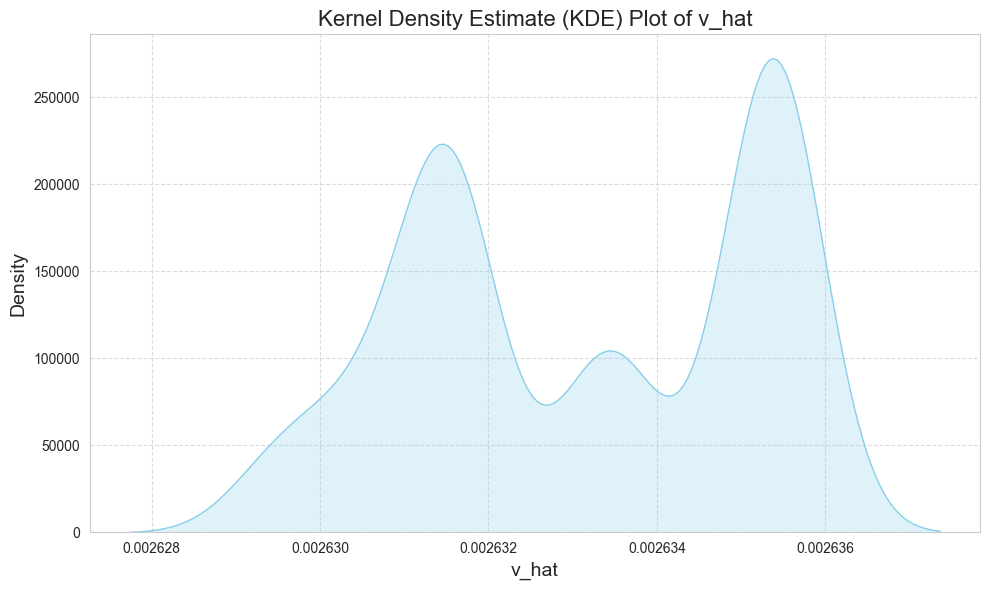

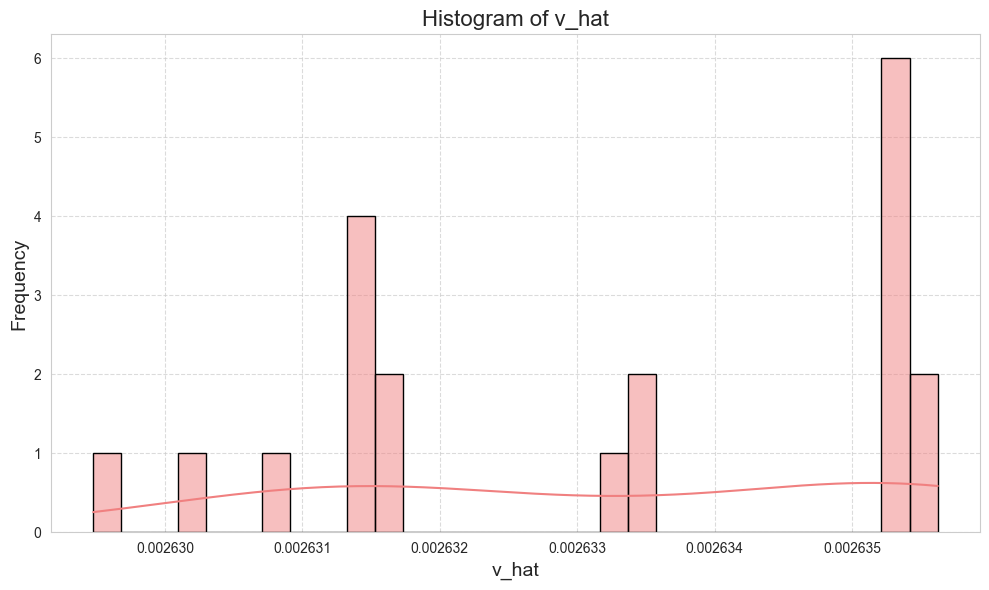

In [26]:
v_hat_cw , omega_hat_cw , gamma_hat_cw = calculate_values(dfcw)

visualize_dataframe(v_hat_cw , "v_hat")

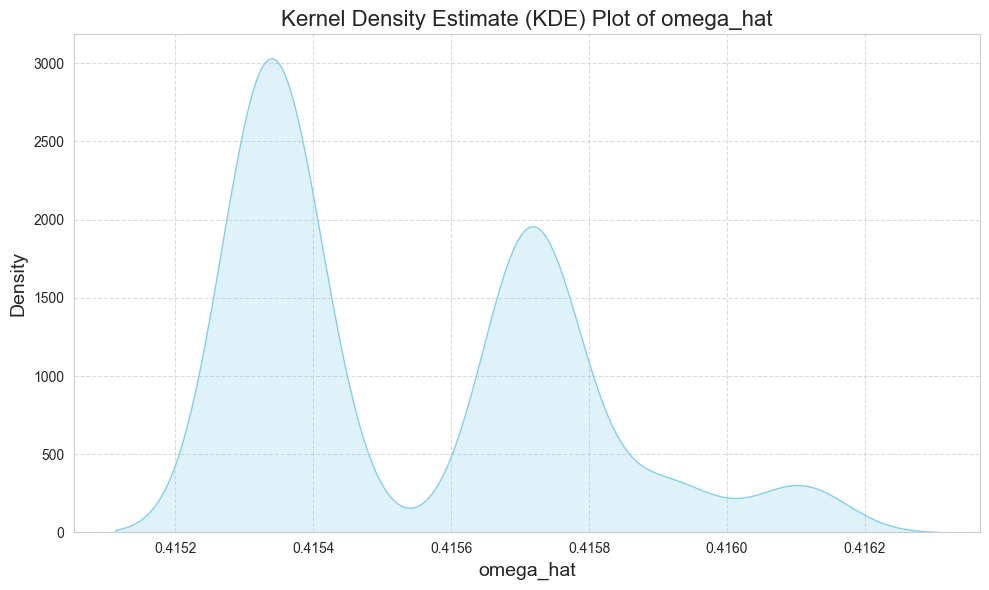

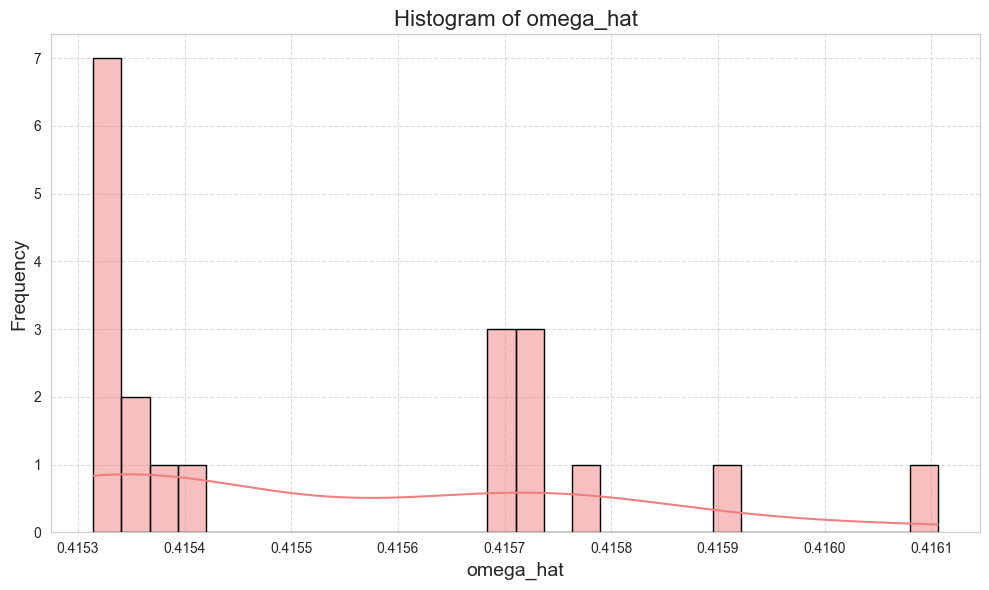

In [18]:
visualize_dataframe(omega_hat_cw , "omega_hat")

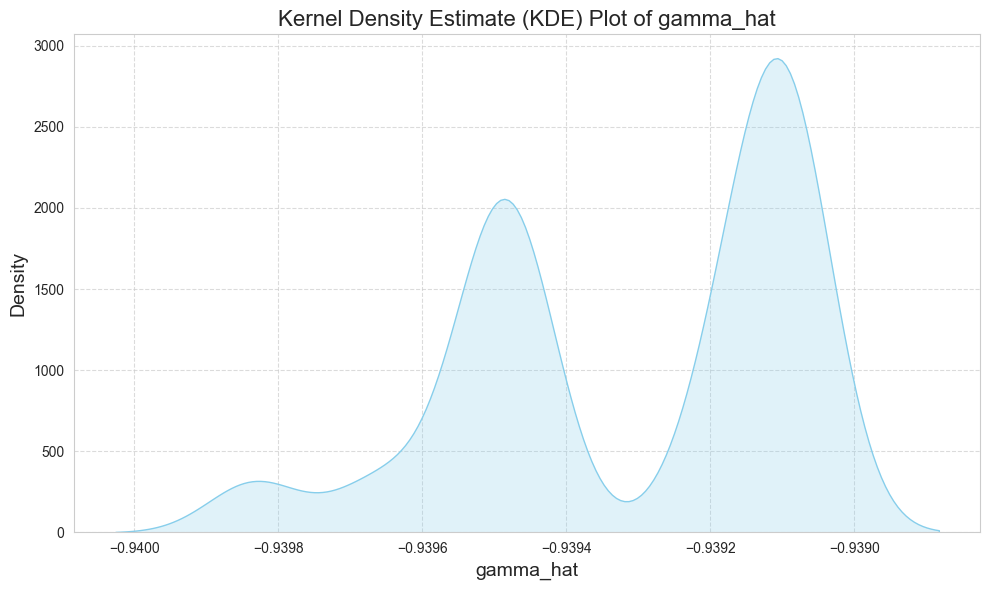

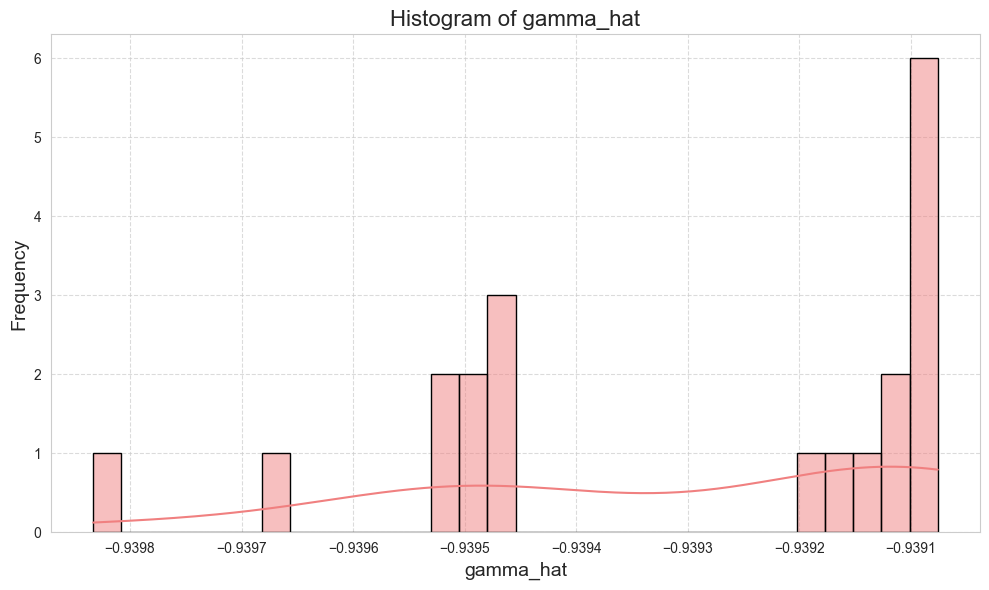

In [19]:
visualize_dataframe(gamma_hat_cw , "gamma_hat")

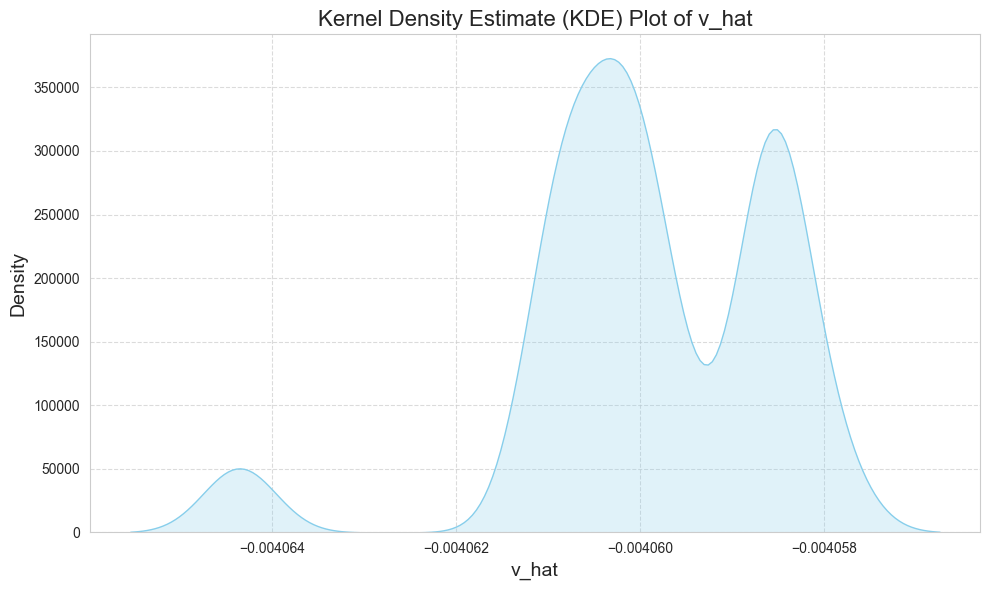

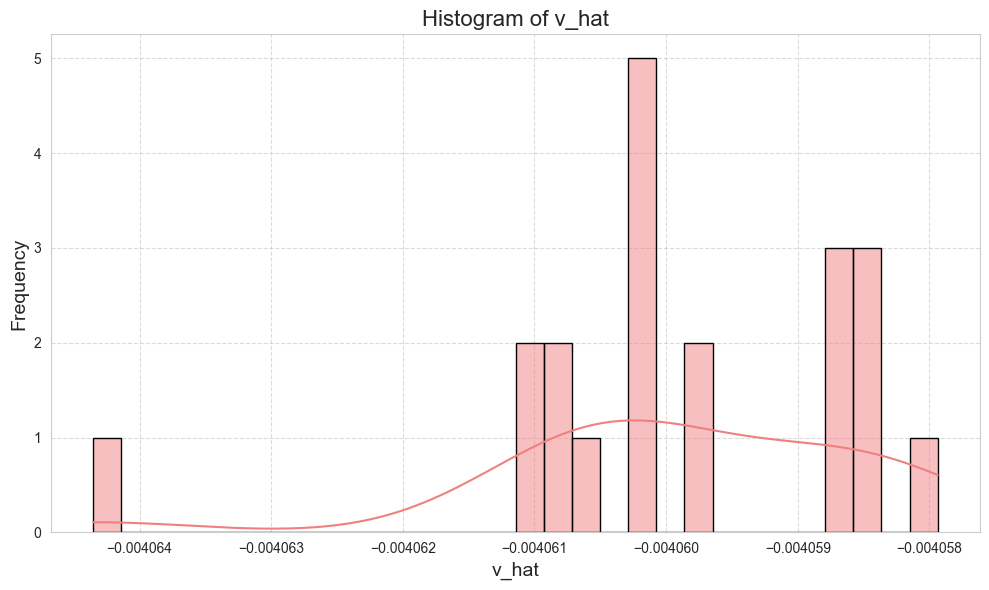

In [20]:
v_hat_ccw , omega_hat_ccw , gamma_hat_ccw = calculate_values(dfccw)
visualize_dataframe(v_hat_ccw , "v_hat")

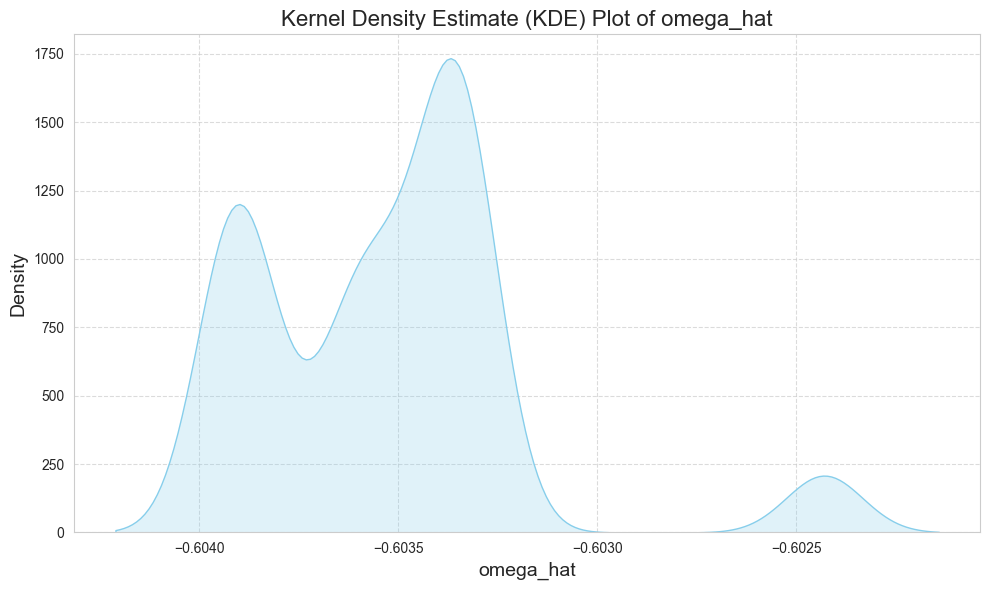

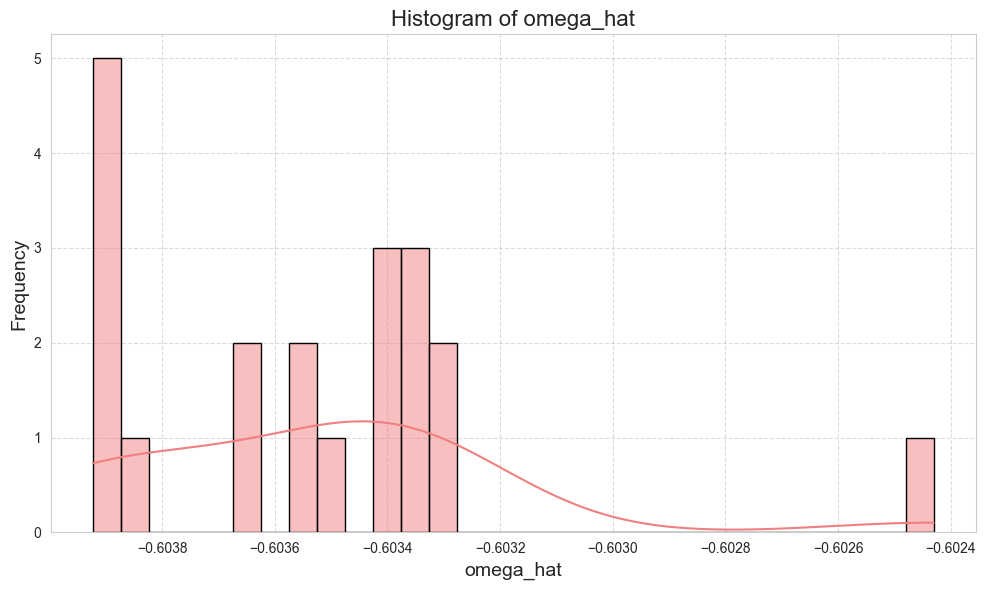

In [21]:
visualize_dataframe(omega_hat_ccw , "omega_hat")

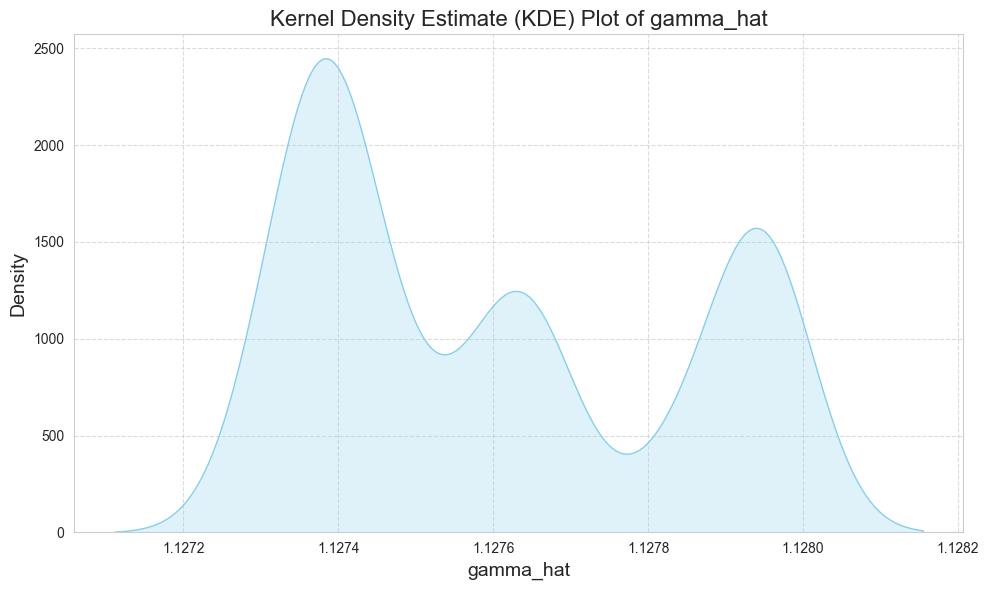

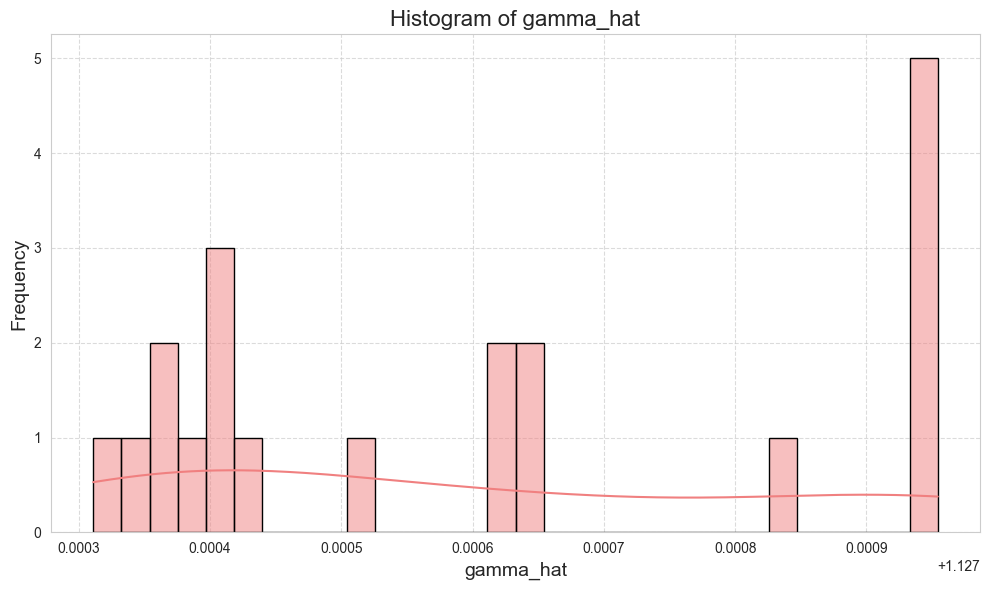

In [22]:
visualize_dataframe(gamma_hat_ccw , "gamma_hat")